In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.linalg import expm
import warnings
warnings.filterwarnings('ignore')

# Quantum chemistry
from pyscf import gto, scf, ao2mo
from openfermion import FermionOperator, normal_ordered, jordan_wigner, get_sparse_operator, count_qubits


## __BUILD HAMILTONIAN__ ##

In [2]:
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma 
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H

In [3]:
def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p,q,r,s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)),
                                0.5 * g
                            )
    return H

    H_mat  : matriks Hamiltonian elektronik (2^n_q × 2^n_q)
    T_mat  : matriks kinetik
    V_mat  : matriks potensial (Ven + Vee)
    E_nuc  : energi repulsi inti
    n_q    : jumlah qubit
    n_orb  : jumlah orbital spasial

In [4]:
def build_hamiltonian(bond_length):
    #bangun molekul
    mol = gto.Mole()
    mol.atom = f'H 0 0 0; H 0 0 {bond_length}'
    mol.basis = 'sto-3g'
    mol.verbose = 0
    mol.build()

    #hartree-fock
    mf = scf.RHF(mol)
    mf.run()
    C = mf.mo_coeff
    n_orb = C.shape[1]
    E_nuc = mol.energy_nuc()

    #integral dalam basis MO
    T_ao = mol.intor('int1e_kin')
    V_ao = mol.intor('int1e_nuc')
    T_mo  = C.T @ T_ao @ C
    V_mo  = C.T @ V_ao @ C
    eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(n_orb, n_orb, n_orb, n_orb)

    #operator fermion
    H_Kin = normal_ordered(build_one_electron(T_mo, n_orb))
    H_VeN = normal_ordered(build_one_electron(V_mo, n_orb))
    H_Vee = normal_ordered(build_two_electron(eri_mo, n_orb))
    
    # Jordan-Wigner → operator qubit
    T_q   = jordan_wigner(H_Kin)
    VeN_q = jordan_wigner(H_VeN)
    Vee_q = jordan_wigner(H_Vee)
    V_q   = VeN_q + Vee_q
    n_q   = count_qubits(T_q + V_q)

    # Dense matrix
    T_mat = get_sparse_operator(T_q, n_qubits=n_q).toarray()
    V_mat = get_sparse_operator(V_q, n_qubits=n_q).toarray()
    H_mat = T_mat + V_mat

    return H_mat, T_mat, V_mat, E_nuc, n_q, n_orb

In [5]:
# ── Uji cepat pada panjang ikatan ekuilibrium ───────────────────────
print("Membangun Hamiltonian untuk R = 0.74 Å ...")
H_test, T_test, V_test, E_nuc_test, n_q_test, n_orb_test = build_hamiltonian(0.74)
evals_test, _ = np.linalg.eigh(H_test)
E_exact_test  = evals_test[0] + E_nuc_test

print(f"  Orbital spasial   : {n_orb_test}")
print(f"  Jumlah qubit      : {n_q_test}")
print(f"  Dimensi Hilbert   : {2**n_q_test} × {2**n_q_test}")
print(f"  E_nuc             : {E_nuc_test:.6f} Ha")
print(f"  E_exact (FCI)     : {E_exact_test:.6f} Ha")

Membangun Hamiltonian untuk R = 0.74 Å ...


  Orbital spasial   : 2
  Jumlah qubit      : 4
  Dimensi Hilbert   : 16 × 16
  E_nuc             : 0.715104 Ha
  E_exact (FCI)     : -1.137284 Ha


## __QUANTUM CIRCUIT: ANSATZ__ ##

In [6]:
#gate primitives
def ry_gate(theta):
    c, s = np.cos(theta/2), np.sin(theta/2)
    return np.array([[c,-s], [s,c]], dtype=complex)

def kron_gate(gate_2x2, qubit, n_qubits):
    ops = [np.eye(2, dtype=complex)] * n_qubits
    ops[qubit] = gate_2x2
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result

def cnot_full(n_qubits, control, target):
    dim = 2 ** n_qubits
    mat = np.zeros((dim, dim), dtype=complex)
    for j in range(dim):
        ctrl_bit = (j >> (n_qubits - 1 - control)) & 1
        if ctrl_bit:
            tgt_pos = n_qubits - 1 - target
            i = j ^ (1 << tgt_pos)
        else:
            i = j
        mat[i, j] = 1.0
    return mat

def build_linear_entangling_layer(n_qubits):
    mat = np.eye(2 ** n_qubits, dtype=complex)
    for q in range(n_qubits - 1):
        mat = cnot_full(n_qubits, q, q + 1) @ mat
    return mat

In [7]:
#inisialisasi state dengan hartee fock
def prepare_hf_state(n_qubits, n_electrons):
    psi = np.zeros(2 ** n_qubits, dtype=complex)
    hf_idx = sum(1 << (n_qubits - 1 - i) for i in range(n_electrons))
    psi[hf_idx] = 1.0
    return psi

    params      : array parameter θ (panjang = n_qubits × (depth+1))
    n_qubits    : jumlah qubit
    n_electrons : jumlah elektron (untuk inisialisasi HF state)
    depth       : jumlah lapisan Ry-CNOT
    cnot_layer  : matrix CNOT entangling (precomputed)

In [8]:
#hardware efficient ansantz
'''
def prepare_ansatz(params, n_qubits, n_electrons, depth, cnot_layer):
    psi = prepare_hf_state(n_qubits, n_electrons)
    idx = 0

    for d in range(depth + 1):
        # Lapisan Ry pada semua qubit secara berurutan
        for q in range(n_qubits):
            Ry  = kron_gate(ry_gate(params[idx]), q, n_qubits)
            psi = Ry @ psi
            idx += 1

        # Lapisan CNOT entangling (kecuali setelah Ry layer terakhir)
        if d < depth:
            psi = cnot_layer @ psi

    return psi
'''

'\ndef prepare_ansatz(params, n_qubits, n_electrons, depth, cnot_layer):\n    psi = prepare_hf_state(n_qubits, n_electrons)\n    idx = 0\n\n    for d in range(depth + 1):\n        # Lapisan Ry pada semua qubit secara berurutan\n        for q in range(n_qubits):\n            Ry  = kron_gate(ry_gate(params[idx]), q, n_qubits)\n            psi = Ry @ psi\n            idx += 1\n\n        # Lapisan CNOT entangling (kecuali setelah Ry layer terakhir)\n        if d < depth:\n            psi = cnot_layer @ psi\n\n    return psi\n'

In [9]:
#ansatz UCCSD
from scipy.linalg import expm

# ── UCCSD: Generator Eksitasi ────────────────────────────────────────

def build_single_excitation_generator(i, a, n_qubits):
    """
    Generator single excitation: G = c†_a c_i - c†_i c_a
    Setelah Jordan-Wigner mapping → matriks Hermitian antisimetrik
    """
    op = (FermionOperator(((a, 1), (i, 0))) -
          FermionOperator(((i, 1), (a, 0))))
    qubit_op = jordan_wigner(op)
    G = get_sparse_operator(qubit_op, n_qubits=n_qubits).toarray()
    return G

def build_double_excitation_generator(i, j, a, b, n_qubits):
    """
    Generator double excitation: G = c†_a c†_b c_j c_i - h.c.
    Setelah Jordan-Wigner mapping → matriks Hermitian antisimetrik
    """
    op = (FermionOperator(((a, 1), (b, 1), (j, 0), (i, 0))) -
          FermionOperator(((i, 1), (j, 1), (b, 0), (a, 0))))
    qubit_op = jordan_wigner(op)
    G = get_sparse_operator(qubit_op, n_qubits=n_qubits).toarray()
    return G

def get_uccsd_excitations(n_electrons, n_qubits):
    """
    Enumerate semua pasangan (i→a) single dan (ij→ab) double excitation.
    Spin orbital: 0..n_electrons-1 = occupied, n_electrons..n_qubits-1 = virtual
    """
    n_occ = n_electrons

    singles = [
        (i, a)
        for i in range(n_occ)
        for a in range(n_occ, n_qubits)
    ]
    doubles = [
        (i, j, a, b)
        for i in range(n_occ)
        for j in range(i + 1, n_occ)
        for a in range(n_occ, n_qubits)
        for b in range(a + 1, n_qubits)
    ]
    return singles, doubles

def count_uccsd_params(n_electrons, n_qubits):
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)
    return len(singles) + len(doubles)

def prepare_ansatz(params, n_qubits, n_electrons, **kwargs):
    """
    UCCSD ansatz (Trotterisasi):
        |ψ(θ)⟩ = [∏_k e^(θ_k G_k)] |HF⟩
    G_k = generator single/double excitation setelah JW mapping.
    kwargs diabaikan (kompatibel dgn signature lama yg pakai depth/cnot_layer)
    """
    psi = prepare_hf_state(n_qubits, n_electrons)
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)

    idx = 0

    # Single excitations: T1
    for (i, a) in singles:
        G = build_single_excitation_generator(i, a, n_qubits)
        U = expm(params[idx] * G)
        psi = U @ psi
        idx += 1

    # Double excitations: T2
    for (i, j, a, b) in doubles:
        G = build_double_excitation_generator(i, j, a, b, n_qubits)
        U = expm(params[idx] * G)
        psi = U @ psi
        idx += 1

    return psi

In [10]:
# ── Konfigurasi Global ───────────────────────────────────────────────
N_QUBITS    = 4          # 2 orbital spasial × 2 spin = 4 qubit
N_ELECTRONS = 2          # H₂ memiliki 2 elektron
#DEPTH       = 2          # kedalaman ansatz
N_PARAMS    = count_uccsd_params(N_ELECTRONS, N_QUBITS)   # = 12 parameter

print(f"Konfigurasi ansatz UCCSD:")
print(f"  n_qubits    = {N_QUBITS}")
print(f"  n_electrons = {N_ELECTRONS}")

singles, doubles = get_uccsd_excitations(N_ELECTRONS, N_QUBITS)
print(f"  Single excitations : {singles}  → {len(singles)} params")
print(f"  Double excitations : {doubles}  → {len(doubles)} params")
print(f"  Total params       = {N_PARAMS}  (vs 12 di HEA depth=2)")

# Verifikasi HF state
psi_hf_demo = prepare_hf_state(N_QUBITS, N_ELECTRONS)
hf_index    = np.argmax(np.abs(psi_hf_demo))


#print(f"  depth       = {DEPTH}")
print(f"  n_params    = {N_PARAMS}  (Ry rotations)")
print(f"  HF state    = |1100⟩  (index {hf_index} dari {2**N_QUBITS} basis states)")
#print(f"  CNOT layer  = precomputed {CNOT_LAYER.shape} matrix")


Konfigurasi ansatz UCCSD:
  n_qubits    = 4
  n_electrons = 2
  Single excitations : [(0, 2), (0, 3), (1, 2), (1, 3)]  → 4 params
  Double excitations : [(0, 1, 2, 3)]  → 1 params
  Total params       = 5  (vs 12 di HEA depth=2)
  n_params    = 5  (Ry rotations)
  HF state    = |1100⟩  (index 12 dari 16 basis states)


## __BUILD VQE__ ##

In [11]:
#nilai ekspektasi
def expect_value(psi, H_mat):
    return float(np.real(psi.conj() @ H_mat @ psi))

    params      : parameter ansatz θ saat ini (array float)
    H_mat       : matriks Hamiltonian elektronik
    n_qubits    : jumlah qubit
    n_electrons : jumlah elektron
    depth       : kedalaman ansatz
    cnot_layer  : precomputed CNOT matrix
    history     : list yang akan diisi dengan nilai E tiap iterasi

In [12]:
#optimizer klasik untuk menghitung E(0) dan menyimpan riwayat energi tiap iterasi
def optimizer_cl(params, H_mat, n_qubits, n_electrons, history):
    psi = prepare_ansatz(params, n_qubits, n_electrons)
    E = expect_value(psi, H_mat)
    history.append(E)
    return E

Jalankan VQE: minimasi E(θ) = ⟨ψ(θ)|H|ψ(θ)⟩ dengan optimizer klasik.

In [13]:
def run_vqe(H_mat, n_qubits, n_electrons, depth=None, cnot_layer=None,
            method='COBYLA', n_restarts=5, seed=42, verbose=False):
    #if cnot_layer is None:
        #cnot_layer = build_linear_entangling_layer(n_qubits)

    rng      = np.random.RandomState(seed)
    n_params = count_uccsd_params(n_electrons, n_qubits)
    best     = {'E_vqe': np.inf, 'energy_history': [], 'n_iters': 0}

    opts_map = {
        'COBYLA'     : {'maxiter': 3000, 'rhobeg': 0.5},
        #'Nelder-Mead': {'maxiter': 5000, 'xatol': 1e-8, 'fatol': 1e-8},
        'BFGS'       : {'maxiter': 1000, 'gtol': 1e-8},
        'L-BFGS-B'   : {'maxiter': 1000, 'ftol': 1e-12},
    }
    opts = opts_map.get(method, {'maxiter': 2000})

    for trial in range(n_restarts):
        history = []

        # Paruh pertama: θ₀ kecil (dekat identitas → dekat HF state)
        # Paruh kedua : θ₀ lebar (eksplorasi ruang parameter)
        if trial < n_restarts // 2:
            theta0 = rng.uniform(-0.3, 0.3, n_params)
        else:
            theta0 = rng.uniform(-np.pi, np.pi, n_params)

        res = minimize(
            optimizer_cl,
            theta0,
            args=(H_mat, n_qubits, n_electrons, history),
            method=method,
            options=opts
        )

        if verbose:
            print(f"  Restart {trial+1}/{n_restarts}: "
                  f"E = {res.fun:.6f} Ha | {len(history):4d} iterasi | "
                  f"success={res.success}")

        if res.fun < best['E_vqe']:
            best = {
                'E_vqe'          : res.fun,
                'optimal_params' : res.x.copy(),
                'energy_history' : history.copy(),
                'n_iters'        : len(history),
                'trial'          : trial + 1,
                'success'        : res.success
            }

    return best

## __MENCOBA VQE PADA BOND LENGTH EKUILIBRIUM (R = 0.74 Å)__ ##

In [14]:
R_DEMO = 0.74  # Å — panjang ikatan ekuilibrium H₂

print(f"  VQE Demo: H₂, R = {R_DEMO} Å, Basis STO-3G")

  VQE Demo: H₂, R = 0.74 Å, Basis STO-3G


In [15]:
#hamiltonian
H_demo, T_demo, V_demo, E_nuc_demo, n_q_demo, _ = build_hamiltonian(R_DEMO)
CNOT_DEMO = build_linear_entangling_layer(n_q_demo)
print(f"\n[1] Hamiltonian: n_qubits={n_q_demo}, dim={2**n_q_demo}×{2**n_q_demo}")

#energi eksak (FCI diagonalisasi)
evals_d, evecs_d = np.linalg.eigh(H_demo)
E_exact_d = evals_d[0] + E_nuc_demo
print(f"[2] E_exact (FCI)  = {E_exact_d:.8f} Ha")

#energi hartee fock pada ansatz theta=0
psi_hf_d = prepare_hf_state(n_q_demo, N_ELECTRONS)
E_hf_d = expect_value(psi_hf_d, H_demo) + E_nuc_demo
print(f"[3] E_HF (θ=0)     = {E_hf_d:.8f} Ha  |  error = {abs(E_hf_d - E_exact_d):.2e} Ha")

#jalanin VQE
vqe_d = run_vqe(
    H_demo, n_q_demo, N_ELECTRONS,
    depth      = None,
    cnot_layer = None,
    method     = 'COBYLA',
    n_restarts = 5,
    seed       = 42,
    verbose    = True
)

E_vqe_d  = vqe_d['E_vqe'] + E_nuc_demo
err_vqe_d = abs(E_vqe_d - E_exact_d)
corr_pct  = (E_hf_d - E_vqe_d) / (E_hf_d - E_exact_d) * 100

print(f"\n[5] Hasil Akhir VQE:")
print(f"    E_VQE   = {E_vqe_d:.8f} Ha")
print(f"    E_exact = {E_exact_d:.8f} Ha")
print(f"    |ΔE|    = {err_vqe_d:.2e} Ha")


[1] Hamiltonian: n_qubits=4, dim=16×16
[2] E_exact (FCI)  = -1.13728383 Ha
[3] E_HF (θ=0)     = -1.11675931 Ha  |  error = 2.05e-02 Ha
  Restart 1/5: E = -1.852388 Ha |   98 iterasi | success=True
  Restart 2/5: E = -1.852388 Ha |   88 iterasi | success=True
  Restart 3/5: E = -1.852388 Ha |   84 iterasi | success=True
  Restart 4/5: E = -1.852388 Ha |   87 iterasi | success=True
  Restart 5/5: E = -1.852388 Ha |  108 iterasi | success=True

[5] Hasil Akhir VQE:
    E_VQE   = -1.13728383 Ha
    E_exact = -1.13728383 Ha
    |ΔE|    = 5.07e-09 Ha


In [16]:
# Fidelity
psi_opt_d    = prepare_ansatz(vqe_d['optimal_params'], n_q_demo,
                               N_ELECTRONS)
psi_exact_d  = evecs_d[:, 0]
fidelity_d   = abs(psi_opt_d.conj() @ psi_exact_d) ** 2
print(f"    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = {fidelity_d:.6f}")

    Fidelity |⟨ψ_VQE|ψ_FCI⟩|² = 1.000000


## __KURVA ENERGI POTENSIAL__ ##

In [17]:
#trotterisasi
def suzuki_trotter(T_mat, V_mat, dt, n_steps):
    """Second-order Suzuki-Trotter time evolution U(t) = e^{-iHt}."""
    V_half  = expm(-1j * V_mat * dt / 2)
    T_full  = expm(-1j * T_mat * dt)
    H_step  = V_half @ T_full @ V_half
    U       = np.eye(H_step.shape[0], dtype=complex)
    for _ in range(n_steps):
        U = H_step @ U
    return U

In [18]:
bond_lengths = np.array([
    0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0,
    1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.0
])

DT      = 0.05
N_STEPS = 20

In [19]:
#looping
results = []
CHEM_ACC = 1.6e-3   # Hartree
print(f"{'─'*77}")
print(f"  {'R(Å)':>5} │ {'E_exact(Ha)':>13} │ {'E_VQE(Ha)':>13} │ "
      f"{'E_Trotter(Ha)':>13} │ {'|ΔE_VQE|(Ha)':>12}")
print(f"{'─'*77}")

for R in bond_lengths:
    #hamiltonian 
    H_mat, T_mat, V_mat, E_nuc, n_q, _ = build_hamiltonian(R)
    cnot_lyr = build_linear_entangling_layer(n_q)

    #eksak
    evals, evecs = np.linalg.eigh(H_mat)
    E_exact = evals[0] + E_nuc
    psi0    = evecs[:, 0]

    #VQE
    vqe_res  = run_vqe(H_mat, n_q, N_ELECTRONS,
                        depth=None, cnot_layer=None,
                        method='COBYLA', n_restarts=5,
                        seed=42, verbose=False)
    E_vqe    = vqe_res['E_vqe'] + E_nuc
    delta_v  = abs(E_vqe - E_exact)

    #suzuki-trotter
    U_trot       = suzuki_trotter(T_mat, V_mat, DT, N_STEPS)
    psi_trot     = U_trot @ psi0
    psi_trot    /= np.linalg.norm(psi_trot)
    E_trot       = expect_value(psi_trot, H_mat) + E_nuc
    delta_t      = abs(E_trot - E_exact)

    results.append({
        'bond_length'   : R,
        'E_exact'       : E_exact,
        'E_vqe'         : E_vqe,
        'E_trotter'     : E_trot,
        'delta_vqe'     : delta_v,
        'delta_trotter' : delta_t,
        'n_iters_vqe'   : vqe_res['n_iters'],
        'history_vqe'   : vqe_res['energy_history'],
        'E_nuc'         : E_nuc,
    })

    print(f"  {R:5.2f}   │  {E_exact:11.6f}  │  {E_vqe:11.6f}  │  "
          f"{E_trot:11.6f}  │  {delta_v:.2e}")

─────────────────────────────────────────────────────────────────────────────
   R(Å) │   E_exact(Ha) │     E_VQE(Ha) │ E_Trotter(Ha) │ |ΔE_VQE|(Ha)
─────────────────────────────────────────────────────────────────────────────
   0.50   │    -1.055160  │    -1.055160  │    -1.055160  │  5.71e-09
   0.60   │    -1.116286  │    -1.116286  │    -1.116286  │  3.02e-09
   0.70   │    -1.136189  │    -1.136189  │    -1.136189  │  5.36e-09
   0.74   │    -1.137284  │    -1.137284  │    -1.137284  │  5.07e-09
   0.80   │    -1.134148  │    -1.134148  │    -1.134148  │  2.31e-09
   0.90   │    -1.120560  │    -1.120560  │    -1.120560  │  3.12e-09
   1.00   │    -1.101150  │    -1.101150  │    -1.101150  │  2.43e-09
   1.20   │    -1.056741  │    -1.056741  │    -1.056741  │  1.83e-09
   1.40   │    -1.015468  │    -1.015468  │    -1.015468  │  1.67e-09
   1.60   │    -0.983473  │    -0.983473  │    -0.983473  │  2.88e-09
   1.80   │    -0.961817  │    -0.961817  │    -0.961817  │  5.28e-10
   

In [20]:
df = pd.DataFrame([{
    'R (Å)'          : f"{r['bond_length']:.2f}",
    'E_exact (Ha)'   : f"{r['E_exact']:.6f}",
    'E_VQE (Ha)'     : f"{r['E_vqe']:.6f}",
    'E_Trotter (Ha)' : f"{r['E_trotter']:.6f}",
    '|ΔE_VQE| (Ha)'  : f"{r['delta_vqe']:.2e}",
    '|ΔE_Trot| (Ha)' : f"{r['delta_trotter']:.2e}",
    'Iter VQE'       : r['n_iters_vqe'],
    'Chem.Acc.'      : '✓' if r['delta_vqe'] < 1.6e-3 else '✗',
} for r in results])

print("Tabel Perbandingan Lengkap:")
print(df.to_string(index=False))

Tabel Perbandingan Lengkap:
R (Å) E_exact (Ha) E_VQE (Ha) E_Trotter (Ha) |ΔE_VQE| (Ha) |ΔE_Trot| (Ha)  Iter VQE Chem.Acc.
 0.50    -1.055160  -1.055160      -1.055160      5.71e-09       6.75e-08       105         ✓
 0.60    -1.116286  -1.116286      -1.116286      3.02e-09       4.03e-08        80         ✓
 0.70    -1.136189  -1.136189      -1.136189      5.36e-09       2.38e-08       107         ✓
 0.74    -1.137284  -1.137284      -1.137284      5.07e-09       1.93e-08        88         ✓
 0.80    -1.134148  -1.134148      -1.134148      2.31e-09       1.42e-08        82         ✓
 0.90    -1.120560  -1.120560      -1.120560      3.12e-09       8.56e-09        82         ✓
 1.00    -1.101150  -1.101150      -1.101150      2.43e-09       5.21e-09        92         ✓
 1.20    -1.056741  -1.056741      -1.056741      1.83e-09       1.90e-09        94         ✓
 1.40    -1.015468  -1.015468      -1.015468      1.67e-09       6.68e-10       100         ✓
 1.60    -0.983473  -0.983473   

In [21]:
# Statistik ringkas
dv = np.array([r['delta_vqe']     for r in results])
dt = np.array([r['delta_trotter'] for r in results])
print(f"\n{'─'*55}")
print(f"Statistik Error Energi:")
print(f"{'':20s} {'VQE':>12}   {'Suzuki-Trotter':>14}")
print(f"{'─'*55}")
print(f"{'Rata-rata |ΔE|':20s} {np.mean(dv):12.2e}   {np.mean(dt):14.2e} Ha")
print(f"{'Maksimum |ΔE|':20s} {np.max(dv):12.2e}   {np.max(dt):14.2e} Ha")
print(f"{'Minimum |ΔE|':20s} {np.min(dv):12.2e}   {np.min(dt):14.2e} Ha")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
Statistik Error Energi:
                              VQE   Suzuki-Trotter
───────────────────────────────────────────────────────
Rata-rata |ΔE|           3.78e-06         1.21e-08 Ha
Maksimum |ΔE|            5.54e-05         6.75e-08 Ha
Minimum |ΔE|             5.28e-10         1.40e-12 Ha
───────────────────────────────────────────────────────


## __PLOT KURVA ENERGI POTENSIAL__ ##

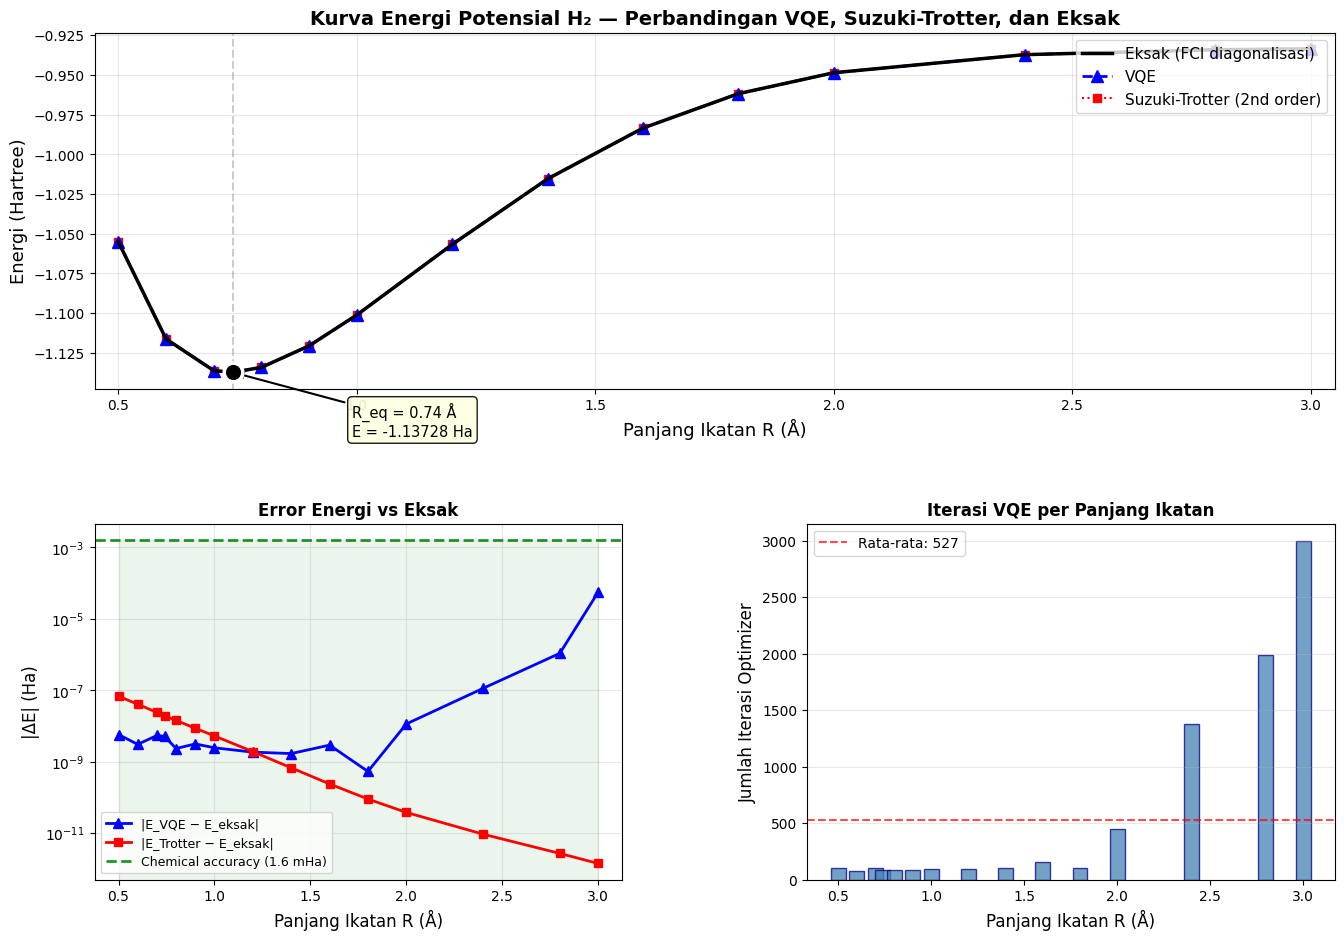

In [23]:
R_arr  = np.array([r['bond_length']   for r in results])
E_ex   = np.array([r['E_exact']        for r in results])
E_vq   = np.array([r['E_vqe']          for r in results])
E_tr   = np.array([r['E_trotter']      for r in results])
dv_arr = np.array([r['delta_vqe']      for r in results])
dt_arr = np.array([r['delta_trotter']  for r in results])

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

# ── 1: Kurva energi potensial ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(R_arr, E_ex, 'k-',   lw=2.5, zorder=5, label='Eksak (FCI diagonalisasi)')
ax1.plot(R_arr, E_vq, 'b^--', lw=2.0, ms=8,  zorder=4, label=f'VQE')
ax1.plot(R_arr, E_tr, 'rs:',  lw=1.5, ms=6,  zorder=3, label='Suzuki-Trotter (2nd order)')

# Tandai minimum eksak
idx_min = np.argmin(E_ex)
ax1.axvline(R_arr[idx_min], color='gray', ls='--', alpha=0.4, lw=1.5)
ax1.scatter([R_arr[idx_min]], [E_ex[idx_min]], s=180, color='black',
            zorder=10, edgecolor='white', lw=2.5)
ax1.annotate(f'R_eq = {R_arr[idx_min]:.2f} Å\nE = {E_ex[idx_min]:.5f} Ha',
             xy=(R_arr[idx_min], E_ex[idx_min]),
             xytext=(R_arr[idx_min]+0.25, E_ex[idx_min]-0.04),
             fontsize=10.5, color='black',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax1.set_xlabel('Panjang Ikatan R (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂ — Perbandingan VQE, Suzuki-Trotter, dan Eksak',
              fontsize=14, weight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(R_arr[0]-0.05, R_arr[-1]+0.05)

# ── 2: Log error vs eksak ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(R_arr, dv_arr, 'b^-', lw=2, ms=7, label='|E_VQE − E_eksak|')
ax2.semilogy(R_arr, dt_arr, 'rs-', lw=2, ms=6, label='|E_Trotter − E_eksak|')
ax2.axhline(1.6e-3, color='green', ls='--', lw=2, alpha=0.85,
            label='Chemical accuracy (1.6 mHa)')
ax2.fill_between(R_arr, 0, 1.6e-3, alpha=0.08, color='green')
ax2.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax2.set_ylabel('|ΔE| (Ha)', fontsize=12)
ax2.set_title('Error Energi vs Eksak', fontsize=12, weight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

# ── 3: Jumlah iterasi VQE ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
bars = ax3.bar(R_arr, [r['n_iters_vqe'] for r in results],
               width=0.08, color='steelblue', alpha=0.75, edgecolor='navy')
ax3.set_xlabel('Panjang Ikatan R (Å)', fontsize=12)
ax3.set_ylabel('Jumlah Iterasi Optimizer', fontsize=12)
ax3.set_title('Iterasi VQE per Panjang Ikatan', fontsize=12, weight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Anotasi rata-rata
avg_iters = np.mean([r['n_iters_vqe'] for r in results])
ax3.axhline(avg_iters, color='red', ls='--', lw=1.5, alpha=0.7,
            label=f'Rata-rata: {avg_iters:.0f}')
ax3.legend(fontsize=10)

plt.show()

Parameter Optimal θ* pada R = 0.74 Å (UCCSD)
───────────────────────────────────────────────────────
  Single excitations (T1):
    θ[0] = -0.000038  (orbital 0 → 2)
    θ[1] = -0.000008  (orbital 0 → 3)
    θ[2] = -0.000035  (orbital 1 → 2)
    θ[3] = +0.000068  (orbital 1 → 3)
  Double excitations (T2):
    θ[4] = -0.112800  (orbital 0,1 → 2,3)
───────────────────────────────────────────────────────

Verifikasi State Optimal:
  E_VQE     = -1.13728383 Ha
  E_exact   = -1.13728383 Ha
  |ΔE|      = 5.07e-09 Ha  ✓ Chemical accuracy
  Fidelity  = 1.000000  (|⟨ψ_VQE|ψ_FCI⟩|²)


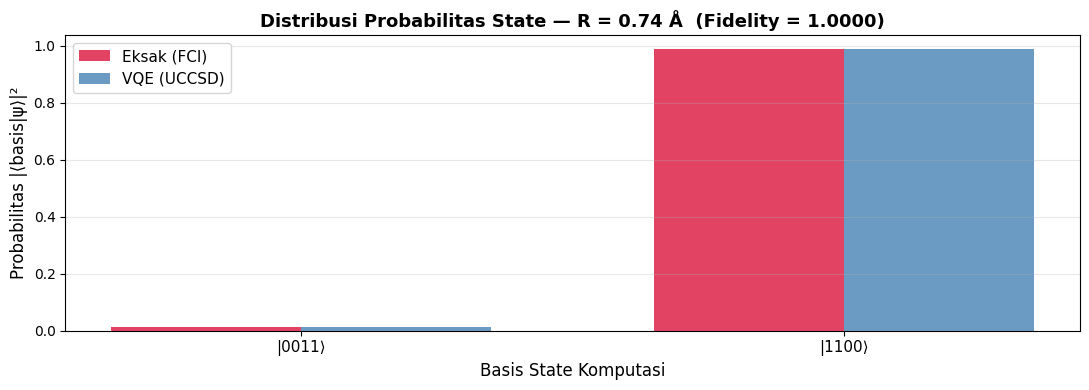


Plot disimpan: vqe_state_distribution.png


In [25]:
# Analisis Parameter Optimal & Verifikasi Final State (R = 0.74 Å)
# ══════════════════════════════════════════════════════════════════════

# Re-build Hamiltonian
H_eq, T_eq, V_eq, E_nuc_eq, n_q_eq, _ = build_hamiltonian(0.74)
vqe_eq = run_vqe(H_eq, n_q_eq, N_ELECTRONS,
                 method='COBYLA', n_restarts=5, seed=42)

theta_star = vqe_eq['optimal_params']
singles, doubles = get_uccsd_excitations(N_ELECTRONS, N_QUBITS)

print("Parameter Optimal θ* pada R = 0.74 Å (UCCSD)")
print(f"{'─'*55}")
print("  Single excitations (T1):")
for k, (i, a) in enumerate(singles):
    print(f"    θ[{k}] = {theta_star[k]:+.6f}  (orbital {i} → {a})")

print("  Double excitations (T2):")
for k, (i, j, a, b) in enumerate(doubles):
    idx = len(singles) + k
    print(f"    θ[{idx}] = {theta_star[idx]:+.6f}  (orbital {i},{j} → {a},{b})")
print(f"{'─'*55}")

# Verifikasi state optimal
psi_star           = prepare_ansatz(theta_star, N_QUBITS, N_ELECTRONS)
evals_eq, evecs_eq = np.linalg.eigh(H_eq)
E_exact_eq         = evals_eq[0] + E_nuc_eq
psi_exact_eq       = evecs_eq[:, 0]

E_final  = expect_value(psi_star, H_eq) + E_nuc_eq
fidelity = abs(psi_star.conj() @ psi_exact_eq) ** 2

print(f"\nVerifikasi State Optimal:")
print(f"  E_VQE     = {E_final:.8f} Ha")
print(f"  E_exact   = {E_exact_eq:.8f} Ha")
print(f"  |ΔE|      = {abs(E_final - E_exact_eq):.2e} Ha  "
      f"{'✓ Chemical accuracy' if abs(E_final - E_exact_eq) < 1.6e-3 else '✗'}")
print(f"  Fidelity  = {fidelity:.6f}  (|⟨ψ_VQE|ψ_FCI⟩|²)")

# Distribusi probabilitas state
probs_vqe   = np.abs(psi_star) ** 2
probs_exact = np.abs(psi_exact_eq) ** 2
basis_labels = [f'|{i:04b}⟩' for i in range(2**N_QUBITS)]

threshold = 0.01
sig_idx = [i for i in range(len(probs_vqe))
           if probs_vqe[i] > threshold or probs_exact[i] > threshold]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(sig_idx))
w = 0.35
ax.bar(x - w/2, probs_exact[sig_idx], w, label='Eksak (FCI)',  color='crimson',   alpha=0.8)
ax.bar(x + w/2, probs_vqe[sig_idx],   w, label='VQE (UCCSD)', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([basis_labels[i] for i in sig_idx], fontsize=11)
ax.set_xlabel('Basis State Komputasi', fontsize=12)
ax.set_ylabel('Probabilitas |⟨basis|ψ⟩|²', fontsize=12)
ax.set_title(f'Distribusi Probabilitas State — R = 0.74 Å  (Fidelity = {fidelity:.4f})',
             fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('vqe_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot disimpan: vqe_state_distribution.png")

## __SOFT__ ##

In [26]:
print(bond_lengths)

[0.5  0.6  0.7  0.74 0.8  0.9  1.   1.2  1.4  1.6  1.8  2.   2.4  2.8
 3.  ]


In [27]:
from scipy.interpolate import CubicSpline

In [28]:
#interpolasi PES VQE ke grid baru
from scipy.interpolate import CubicSpline
R_data = np.array([r['bond_length'] for r in results])
E_data = np.array([r['E_vqe']       for r in results])
E_data -= E_data.min()                        # shift minimum ke 0

# grid SOFT harus mencakup rentang R
d = 6
xMin = R_data.min() - 0.2
#print(xMin)
xMax = R_data.max() + 0.5
#print(xMax)
x = np.linspace(xMin, xMax, num=2**d)

VV = CubicSpline(R_data, E_data)(x)
VV = np.clip(VV, 0, 0.15)
wall = 0.5 * (np.tanh(-(x - xMin - 0.2)*10) +1) * 0.15
VV += wall
print(f'VV = {VV}')

VV = [0.29730207 0.29277778 0.28161352 0.24020948 0.15195258 0.08075623
 0.03571996 0.01262792 0.00310403 0.0012459  0.00420584 0.01026219
 0.01842886 0.02799773 0.03849376 0.0495452  0.0609119  0.0723721
 0.08370539 0.09473454 0.10535877 0.11548525 0.12502171 0.13390643
 0.14212371 0.14966169 0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15       0.15       0.15
 0.15       0.15       0.15       0.15      ]


In [29]:
def vqe_to_soft(results, n_grid_bits=6):
    #konversi output veq ke paramter untuk soft
    R = np.array([r['bond_length'] for r in results])
    E = np.array([r['E_vqe'] for r in results])
    E -= E.min()

    N    = 2**n_grid_bits
    x    = np.linspace(R.min(), R.max(), N)
    VV   = CubicSpline(R, E)(x)

    # Propagator SOFT dari PES baru
    dx   = (x[-1] - x[0]) / (N - 1)
    dp   = 2*np.pi / (x[-1] - x[0])
    p    = np.fft.fftshift(np.arange(N) * dp - N/2 * dp)


    return x, VV, p

    mu = untuk mengontrol energi awal
    alpha = untuk mengontrol lebar → kecepatan dispersi

In [30]:
#wave packet awal psi0 ke posisi ekuilibrium VQE
R_eq_idx = np.argmin([r['E_vqe'] for r in results])
R_eq = results[R_eq_idx]['bond_length']

#untuk pusat gaussian
mu = R_eq + 0.46      
print(mu)
alpha = 10.0    #lebar wave packet (makin besar = makin sempit)

psi = (alpha/np.pi)**0.25 * np.exp(-alpha * (x-mu)**2 * 0.5)
psi /= np.sqrt(np.sum(np.abs(psi)**2))

1.2


In [31]:
#preparation of potensial dan kinetik split propagation
#massa tereduksi H2
#mass = 1    #buat debug
mass = 1836.15 / 2  #~918 a.u
time_step = 0.01

dx = (xMax - xMin)/(2**d-1)

#KE operator
dp = 2*np.pi / (xMax-xMin)
N = 2**d
p = np.fft.fftshift(np.arange(N) * dp - N/2 * dp)

VVd_prop = np.diag(np.exp(-1j*VV*time_step))    #potential propagator
KED_prop = np.diag(np.exp(-1j*p**2/(2*mass)*time_step))  #kinetic propagator

In [32]:
from qiskit.circuit.library import QFT
from qiskit import *
from qiskit.quantum_info import Operator

In [33]:
#quantum SOFT circuit preparation
#inisialisasi circuit kosong
nqubits = d
N_STEPS_SOFT = 10
q_reg = QuantumRegister(nqubits)
c_reg = ClassicalRegister(nqubits)
qc = QuantumCircuit(q_reg, c_reg)

qc.initialize(psi, q_reg[:])

for k in range(N_STEPS_SOFT):
    bound_op = Operator(VVd_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)
    bound_op = Operator(KED_prop)
    qc.append(bound_op, q_reg)
    qc.append(QFT(d, do_swaps=True, inverse=True), q_reg)

In [34]:
#quantum soft circuit execution
from qiskit import transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator(method='statevector')
qc.save_statevector()

qc_transpiled = transpile(qc, simulator)
psin = simulator.run(qc_transpiled).result().get_statevector()
print(psin)

Statevector([ 5.23040707e-03-2.59715449e-04j,
              8.18131887e-03-1.82884292e-04j,
              1.24204210e-02-3.24109708e-04j,
              1.83987254e-02-3.88131525e-04j,
              2.65558046e-02-3.50031543e-04j,
              3.73538279e-02-2.32282492e-04j,
              5.11973451e-02-1.11721569e-04j,
              6.83847074e-02-9.32094652e-06j,
              8.90131292e-02+4.30347622e-05j,
              1.12914656e-01+4.79318118e-05j,
              1.39584731e-01-1.74017154e-05j,
              1.68160093e-01-1.56299291e-04j,
              1.97424439e-01-3.81784347e-04j,
              2.25878433e-01-6.85895532e-04j,
              2.51850140e-01-1.06100246e-03j,
              2.73656000e-01-1.47989596e-03j,
              2.89775538e-01-1.91595555e-03j,
              2.99029228e-01-2.32965554e-03j,
              3.00718356e-01-2.68625379e-03j,
              2.94714577e-01-2.95038266e-03j,
              2.81473849e-01-3.10295345e-03j,
              2.61981125e-01-3.131

In [35]:
#classical soft benchmark
def soft(fxy, emat, Pxy):
    #soft propagation
    out = emat*fxy
    fp = np.fft.fft(out)*Pxy
    out = np.fft.ifft(fp)
    return out

psi_c_init = psi
psi_c = psi_c_init

for i in range(N_STEPS_SOFT):
    psi_c = soft(psi_c, np.diag(VVd_prop), np.diag(KED_prop))

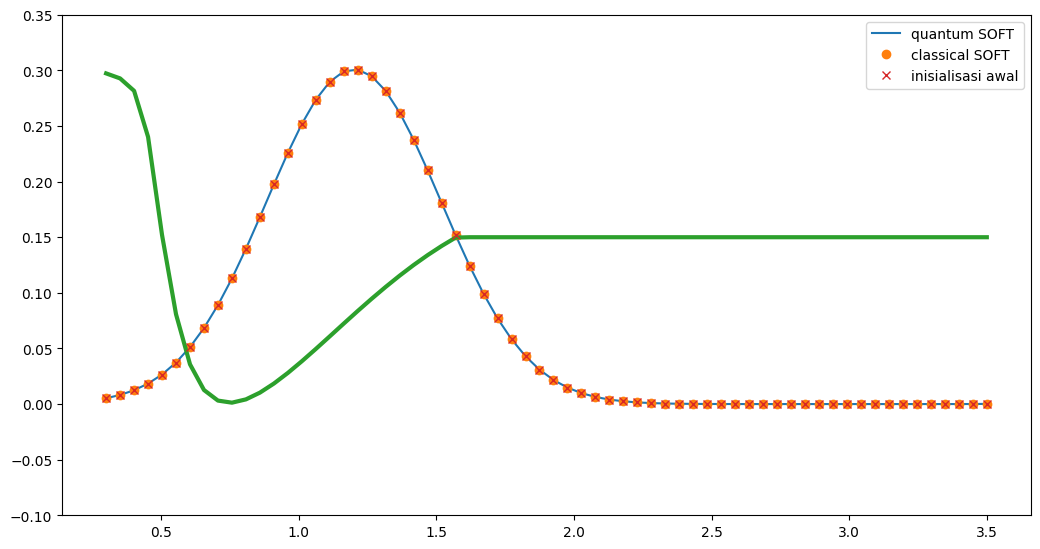

In [36]:
#plotting initial and final wavefunction
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [12.50, 6.50]
#plt.plot(x, np.real(psin), label = 'real')
#plt.plot(x, np.imag(psin), label = 'imag')
plt.plot(x, np.abs(psin), label='quantum SOFT')
plt.plot(x, np.abs(psi_c), 'o', label='classical SOFT')
plt.plot(x, VV, linewidth=3)
plt.plot(x, abs(psi), 'x', label='inisialisasi awal')
leg = plt.legend(loc='upper right')
plt.ylim(-0.1, 0.35)
plt.show()